# Student Churn Prediction

**Goal of this notebook:**
 - Descriptive stats and EDA to undearstand the raw data well enough

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the raw, unfiltered data

In [3]:
raw_path = "../data/raw/dropout.csv" 
df_raw = pd.read_csv(raw_path)

print(df_raw.shape)

(4424, 37)


## 2. Typage des variables

Une description de chaque variable.

In [4]:
type_summary = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isna().sum(),
})
type_summary["exemple_valeurs"] = [
    sorted(df_raw[col].dropna().unique())[:6] for col in df_raw.columns
]
type_summary.sort_values("n_unique", ascending=False)

,dtype,n_unique,n_missing,exemple_valeurs
Curricular units 1st sem (grade),float64,797,0,"[0.0, 9.8, 10.0, 10.16666667, 10.2, 10.21428571]"
Curricular units 2nd sem (grade),float64,782,0,"[0.0, 10.0, 10.16666667, 10.2, 10.25, 10.33333..."
Admission grade,float64,620,0,"[95.0, 95.1, 95.5, 95.8, 96.0, 96.1]"
Previous qualification (grade),float64,101,0,"[95.0, 96.0, 97.0, 99.0, 100.0, 101.0]"
Father's occupation,int64,46,0,"[0, 1, 2, 3, 4, 5]"
Age at enrollment,int64,46,0,"[17, 18, 19, 20, 21, 22]"
Curricular units 1st sem (evaluations),int64,35,0,"[0, 1, 2, 3, 4, 5]"
Father's qualification,int64,34,0,"[1, 2, 3, 4, 5, 6]"
Mother's occupation,int64,32,0,"[0, 1, 2, 3, 4, 5]"
Curricular units 2nd sem (evaluations),int64,30,0,"[0, 1, 2, 3, 4, 5]"


Summary: 
- Aucune valeur manquante détectée.
- Les colonnes `int64` à faible cardinalité sont en réalité des codes catégoriels et non des quantités.

In [5]:
num_continuous = [
    "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)",
    "Admission grade", "Previous qualification (grade)",
    "Unemployment rate", "GDP", "Inflation rate",
]
num_discrete = [
    "Age at enrollment",
    "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (without evaluations)",
]
cat_binary = [
    "Daytime/evening attendance", "International", "Gender", "Scholarship holder",
    "Educational special needs", "Debtor", "Displaced", "Tuition fees up to date",
]
cat_nominal = [
    "Father's occupation", "Mother's occupation", "Father's qualification",
    "Mother's qualification", "Nacionality", "Application mode",
    "Previous qualification", "Course", "Marital Status",
]
cat_ordinal = ["Application order"]

print(len(num_continuous + num_discrete + cat_binary + cat_nominal + cat_ordinal) + 1 == df_raw.shape[1])

True


## 3. Statistiques univariées 

### 1- Variables numériques

Pour chaque variable numérique (continue et discrète), on calcule moyenne, médiane, écart-type, et le nombre de valeurs aberrantes.
L'objectif est d'identifier les variables asymétriques et les colonnes où les valeurs extrêmes pourraient représenter un signal réel.

In [6]:
num_cols = num_continuous + num_discrete

#iqr method to detect outliers
def outlier_count(s: pd.Series) -> int:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum()

univariate_num = pd.DataFrame({
    "mean" : df_raw[num_cols].mean(),
    "median" : df_raw[num_cols].median(),
    "std" : df_raw[num_cols].std(),
    "min" : df_raw[num_cols].min(),
    "max" : df_raw[num_cols].max(),
    "skew" : df_raw[num_cols].skew(),
    "outliers" : df_raw[num_cols].apply(outlier_count)
})
univariate_num.sort_values("skew", ascending=False)

,mean,median,std,min,max,skew,outliers
Curricular units 1st sem (without evaluations),0.137658,0.000000,0.690880,0.00,12.000000,8.207403,294
Curricular units 2nd sem (without evaluations),0.150316,0.000000,0.753774,0.00,12.000000,7.267701,282
Curricular units 2nd sem (credited),0.541817,0.000000,1.918546,0.00,19.000000,4.634820,530
Curricular units 1st sem (credited),0.709991,0.000000,2.360507,0.00,20.000000,4.169049,577
Age at enrollment,23.265145,20.000000,7.587816,17.00,70.000000,2.054988,441
Curricular units 1st sem (enrolled),6.270570,6.000000,2.480178,0.00,26.000000,1.619041,424
Curricular units 1st sem (evaluations),8.299051,8.000000,4.179106,0.00,45.000000,0.976637,158
Curricular units 2nd sem (enrolled),6.232143,6.000000,2.195951,0.00,23.000000,0.788114,369
Curricular units 1st sem (approved),4.706600,5.000000,3.094238,0.00,26.000000,0.766262,180
Admission grade,126.978119,126.100000,14.482001,95.00,190.000000,0.530600,86


- **Visualisation des distributions**


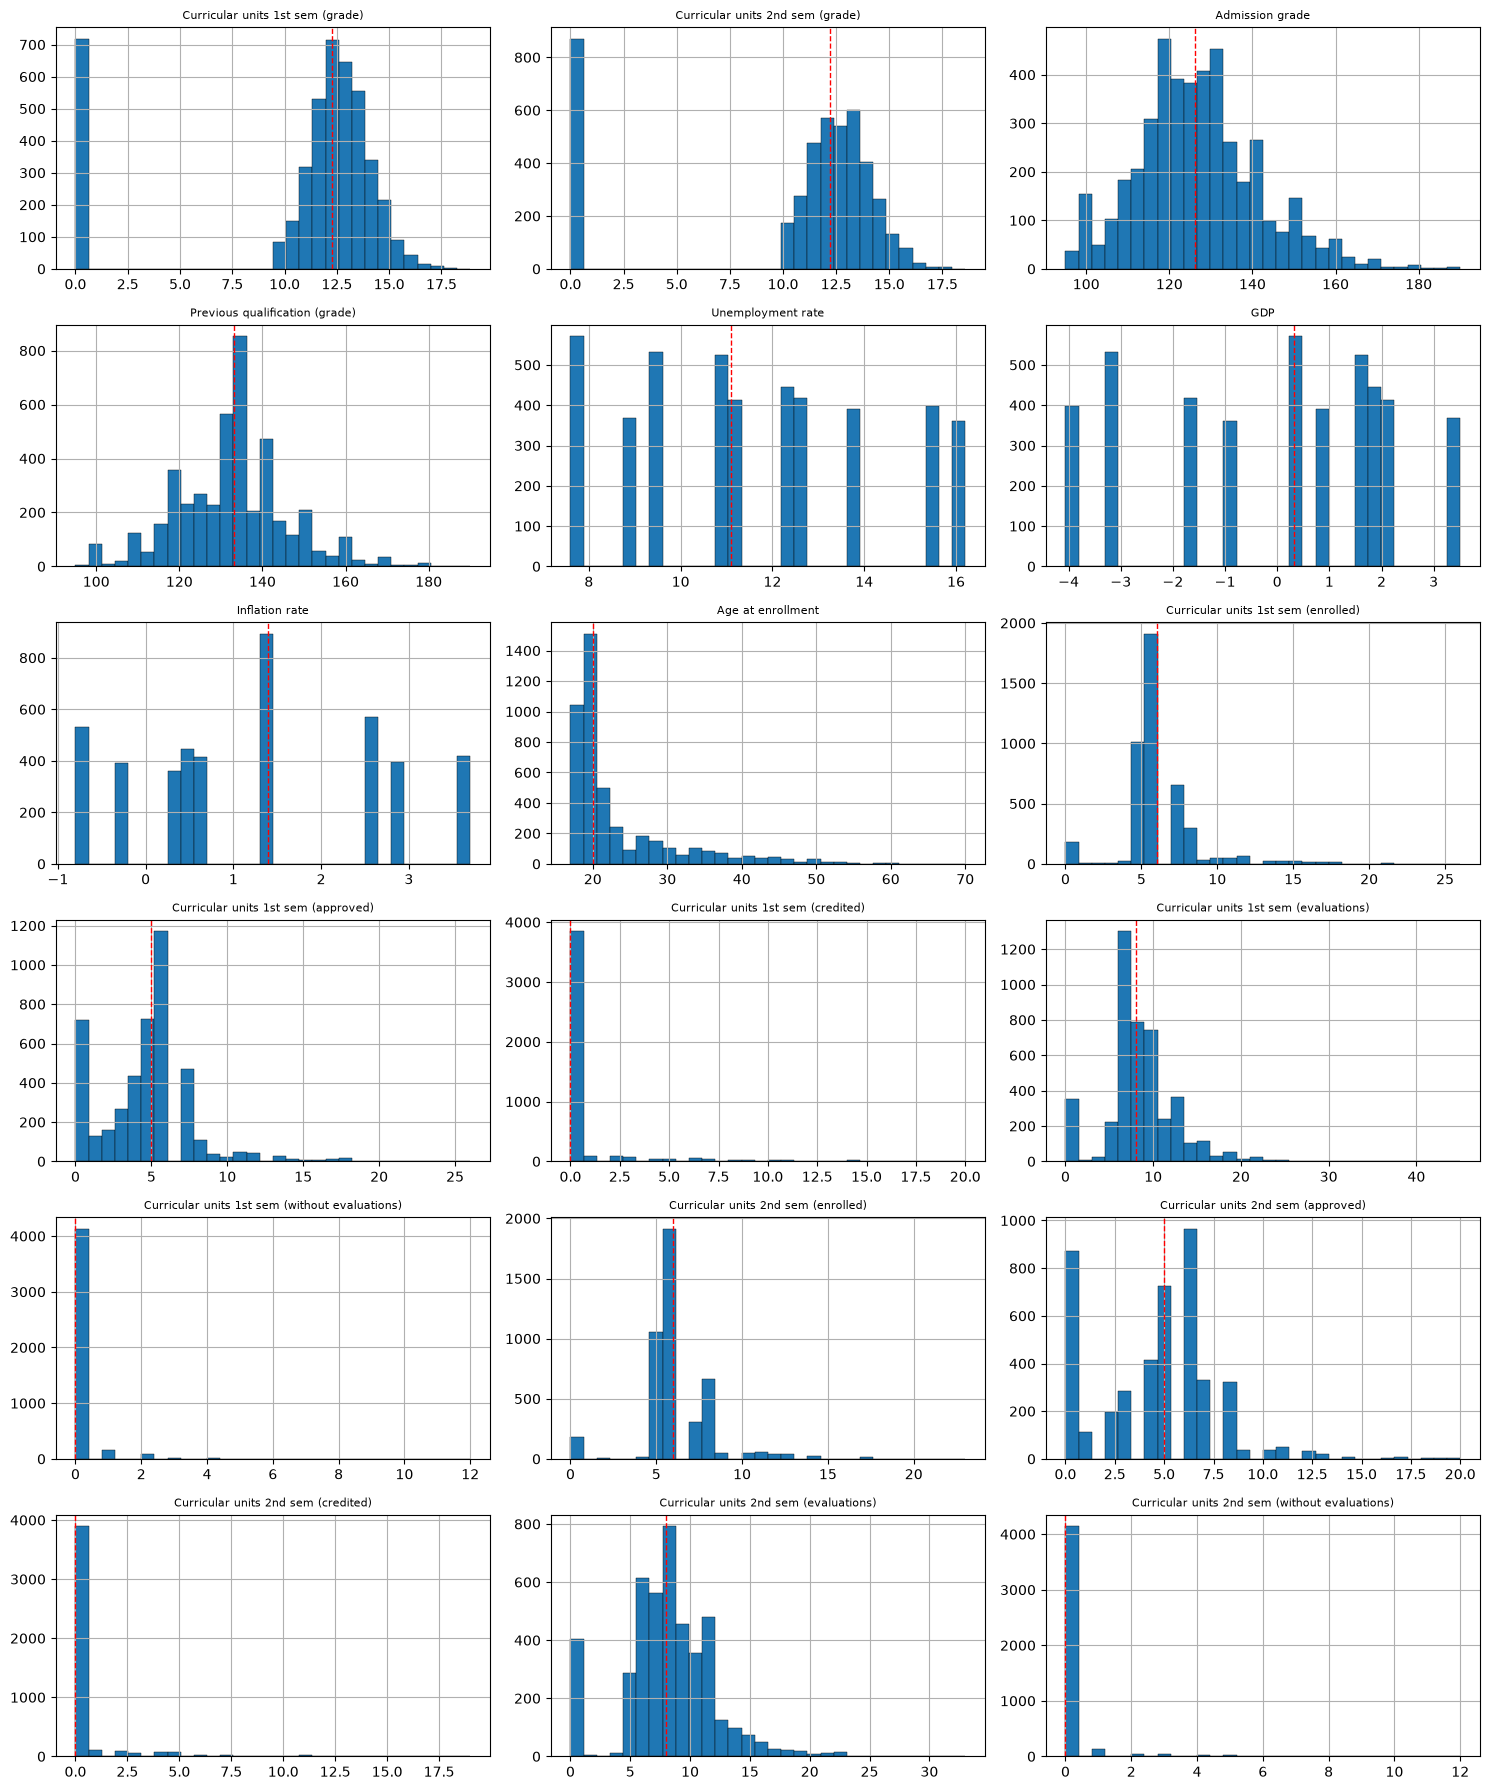

In [8]:
fig, axes = plt.subplots(6, 3, figsize=(15, 18))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    df_raw[col].hist(bins=30, ax=ax, edgecolor="black", linewidth=0.3)
    ax.axvline(df_raw[col].median(), color="red", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=8)

for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()